In [21]:
import pandas as pd
import useful_rdkit_utils as uru
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
import warnings
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from mordred import Calculator, descriptors
from rdkit import Chem

In [22]:
tqdm.pandas()

1. Read the input data from the supporting material for ["Prospective Validation of Machine Learning Algorithms for Absorption, Distribution, Metabolism, and Excretion Prediction: An Industrial Perspective"](https://pubs.acs.org/doi/10.1021/acs.jcim.3c00160)
2. Generate RDKit count fingerprints using useful_rdkit_utils.
3. Create a dictionary mapping SMILES to descriptors. 

In [7]:
df = pd.read_csv("https://raw.githubusercontent.com/molecularinformatics/Computational-ADME/refs/heads/main/ADME_public_set_3521.csv")
df["fp"] = df.SMILES.progress_apply(uru.Smi2Fp().get_np_counts)
fp_dict = dict(df[["SMILES","fp"]].values)

  0%|          | 0/3521 [00:00<?, ?it/s]

In [8]:
df["desc"] = df.SMILES.progress_apply(uru.RDKitDescriptors().calc_smiles)
# Scale the descriptors to keep Ridge happy
desc_pre = uru.DescriptorPreprocessor()
df.desc = desc_pre.fit_transform(np.stack(df.desc)).tolist()
desc_dict = dict(df[["SMILES","desc"]].values)

  0%|          | 0/3521 [00:00<?, ?it/s]

In [23]:
calc = Calculator(descriptors, ignore_3D=True)
df["mol"] = df.SMILES.progress_apply(Chem.MolFromSmiles)
mordred_desc = calc.pandas(df.mol).values.tolist()
mordred_desc_pre = uru.DescriptorPreprocessor()
df["mordred_desc"] = mordred_desc_pre.fit_transform(np.stack(mordred_desc)).tolist()

  0%|          | 0/3521 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████| 3521/3521 [01:33<00:00, 37.61it/s]


Here are a few example wrapper classes which allow us to use any sckit-learn compatible ML model with a few lines of code. 

In [10]:
LGBMRDKitWrapper = uru.WrapperFactory.create_wrapper_class(
    model_class=LGBMRegressor, 
    descriptor_dict=desc_dict,
    class_name="LGBMWrapper",
    verbose=-1
)

FFNNRDKitWrapper = uru.WrapperFactory.create_wrapper_class(
    model_class=FFNNRegressor, 
    descriptor_dict=desc_dict,
    class_name="FFNNWrapper",
)

In [11]:
method_list = [("LGBM",LGBMWrapper),("XGB",XGBWrapper),("Ridge",RidgeWrapper)]
method_name_list = [x[0] for x in method_list]        
group_list = [("butina",uru.get_butina_clusters)] 

# Remove an annoying LGBM warning
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")

In [12]:
%%time
assay_cols = [x for x in df.columns if x.startswith("LOG")]
df_list = []
with tqdm(assay_cols) as pbar:
    for col in pbar:
        tmp_df = df.dropna(subset=col)
        tmp_df["fp"] = tmp_df.SMILES.apply(uru.Smi2Fp().get_np_counts)   
        result_df = uru.cross_validate(tmp_df,
                                       model_list=method_list,
                                       y_col=col,
                                       group_list=group_list)
        result_df['assay'] = col
        df_list.append(result_df)

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

butina:   0%|          | 0/5 [00:00<?, ?it/s]

butina:   0%|          | 0/5 [00:00<?, ?it/s]

butina:   0%|          | 0/5 [00:00<?, ?it/s]

...

butina:   0%|          | 0/5 [00:00<?, ?it/s]

butina:   0%|          | 0/5 [00:00<?, ?it/s]

butina:   0%|          | 0/5 [00:00<?, ?it/s]

butina:   0%|          | 0/5 [00:00<?, ?it/s]

CPU times: user 34min 29s, sys: 9.88 s, total: 34min 39s
Wall time: 1min 28s


In [13]:
r2_df_list = []
mae_df_list = []
for assay,res_df in zip(assay_cols,df_list):
    r2_df, mae_df = uru.get_performance_stats(res_df,
          method_list=method_name_list,y_col=assay)
    r2_df["assay"] = assay
    mae_df["assay"] = assay
    r2_df_list.append(r2_df)
    mae_df_list.append(mae_df)

In [14]:
r2_combo_df = pd.concat(r2_df_list).reset_index(drop=True)
mae_combo_df = pd.concat(mae_df_list).reset_index(drop=True)

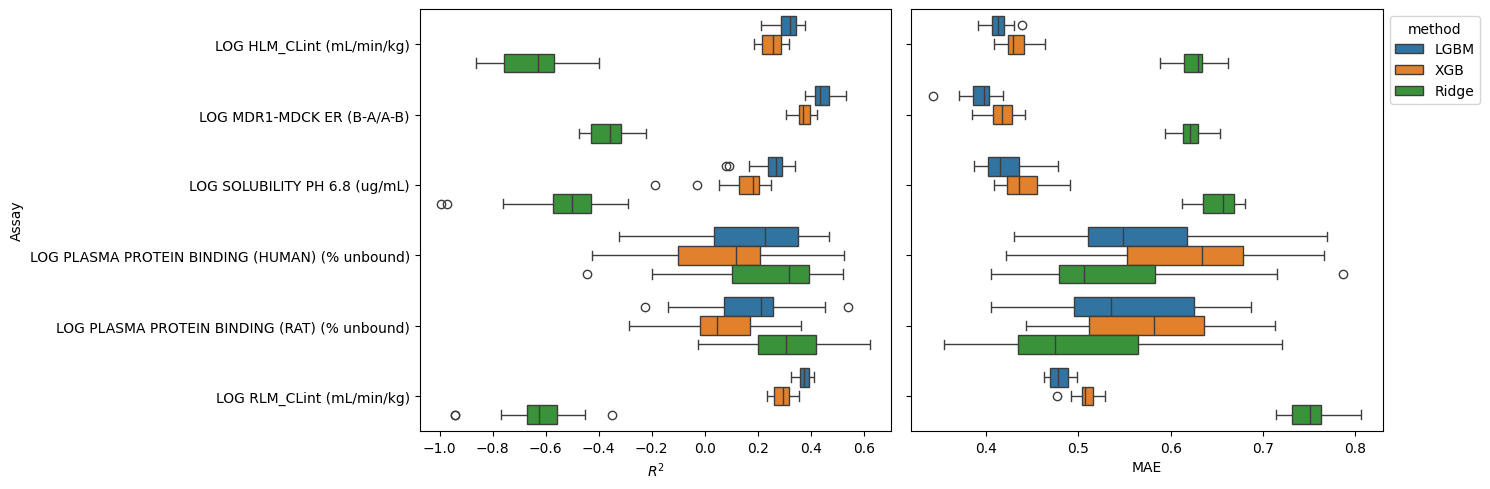

In [15]:
uru.plot_r2_mae(r2_combo_df, mae_combo_df)

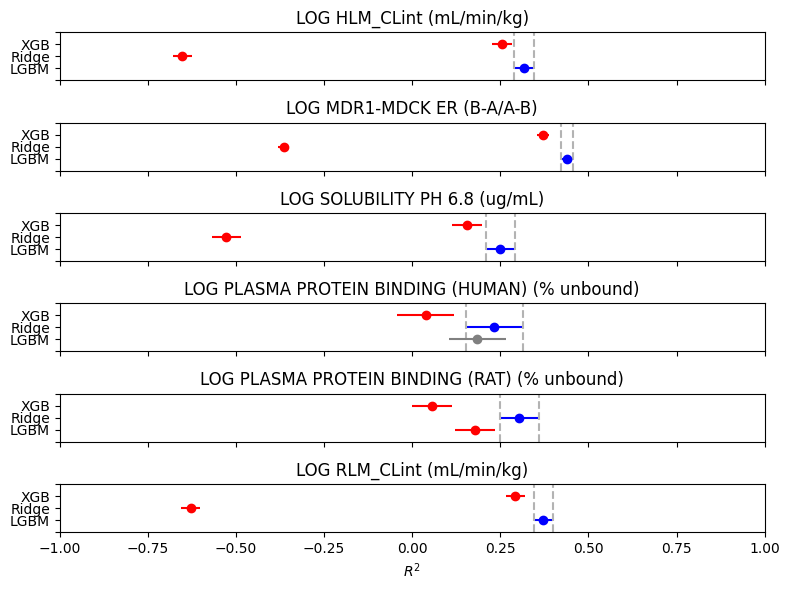

In [16]:
uru.plot_tukey(r2_df_list, assay_cols, "r2",figheight=6)

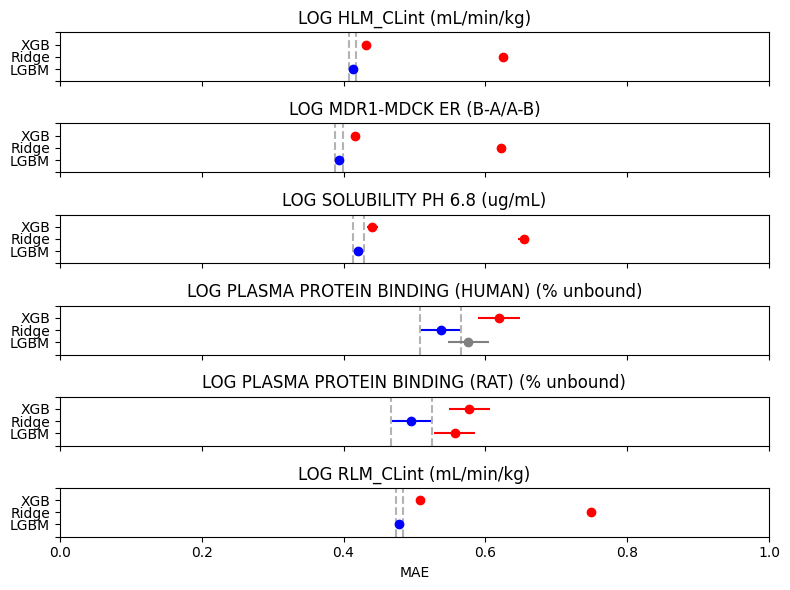

In [17]:
uru.plot_tukey(mae_df_list, assay_cols, "mae",figheight=6)